In [60]:
import pandas as pd

file = 'train.csv'
df = pd.read_csv(file)
df.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,0,22.0,3.0,1.0,2.0,60.0,278.63,0.06,19.56,14.25,...,17,1,1,0,16.0,9.0,38.0,22.0,5.0,False
1,1,14.0,2.0,1.0,2.0,32.0,151.27,0.14,7.00,21.11,...,11,0,1,0,11.0,11.0,18.0,14.0,3.0,False
2,2,11.0,2.0,1.0,2.0,45.0,197.65,0.11,8.05,22.76,...,8,0,1,0,12.0,11.0,28.0,17.0,3.0,False
3,3,8.0,1.0,1.0,1.0,23.0,94.01,0.19,5.25,17.86,...,4,0,2,0,8.0,6.0,16.0,7.0,1.0,True
4,4,11.0,2.0,1.0,2.0,17.0,60.94,0.18,5.63,12.44,...,7,0,2,0,7.0,6.0,10.0,10.0,3.0,False


## definition of each column

In [61]:
# loc              - Total lines of code
# v(g)             - Cyclomatic complexity: number of independent paths through the code (each if/loop/branch adds 1)
# ev(g)            - Essential complexity: how much complexity can't be simplified away, high = poorly structured
# iv(g)            - Design complexity: complexity of the module's calls to other modules
# n                - Halstead program length = total_Op + total_Opnd
# v                - Halstead volume: bits of information needed to encode the program
# l                - Halstead program level: inverse of difficulty, ranges 0-1, higher = simpler
# d                - Halstead difficulty: how hard the code is to understand
# i                - Halstead intelligence: how efficiently the programmer expressed the idea (v / d)
# e                - Halstead effort: estimated mental effort to implement (v * d), can get very large
# b                - Halstead bug estimate: predicted number of bugs (v / 3000)
# t                - Halstead time: estimated seconds to implement (e / 18), moves in lockstep with e
# lOCode           - Lines of pure code only
# lOComment        - Lines of pure comments only
# lOBlank          - Blank lines
# locCodeAndComment - Lines that have both code and a comment on the same line
# uniq_Op          - Number of distinct operators used (e.g. +, =, if)
# uniq_Opnd        - Number of distinct operands used (e.g. variable names, constants)
# total_Op         - Total operator count including repeats
# total_Opnd       - Total operand count including repeats
# branchCount      - Raw count of branches in the code, closely correlated with v(g)
# defects          - TARGET: whether the module had one or more reported bugs (True/False, converted to 0/1)

In [62]:
df.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,...,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,50881.000000,37.347160,5.492684,2.845022,3.498826,96.655995,538.280956,0.111634,13.681881,27.573007,...,1141.357982,22.802453,1.773945,3.979865,0.196604,11.896131,15.596671,57.628116,39.249698,9.839549
std,29376.592059,54.600401,7.900855,4.631262,5.534541,171.147191,1270.791601,0.100096,14.121306,22.856742,...,9862.795472,38.541010,5.902412,6.382358,0.998906,6.749549,18.064261,104.537660,71.692309,14.412769
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25440.500000,13.000000,2.000000,1.000000,1.000000,25.000000,97.670000,0.050000,5.600000,15.560000,...,31.380000,7.000000,0.000000,1.000000,0.000000,8.000000,7.000000,15.000000,10.000000,3.000000
50%,50881.000000,22.000000,3.000000,1.000000,2.000000,51.000000,232.790000,0.090000,9.820000,23.360000,...,125.400000,14.000000,0.000000,2.000000,0.000000,11.000000,12.000000,30.000000,20.000000,5.000000
75%,76321.500000,42.000000,6.000000,3.000000,4.000000,111.000000,560.250000,0.150000,18.000000,34.340000,...,565.920000,26.000000,1.000000,5.000000,0.000000,16.000000,20.000000,66.000000,45.000000,11.000000
max,101762.000000,3442.000000,404.000000,165.000000,402.000000,8441.000000,80843.080000,1.000000,418.200000,569.780000,...,935923.390000,2824.000000,344.000000,219.000000,43.000000,410.000000,1026.000000,5420.000000,3021.000000,503.000000


In [63]:
df.isnull().sum()

id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [64]:
df.shape

(101763, 23)

In [65]:
from IPython.display import HTML, display
import tabulate

# Outlier definition: a value is an outlier if it falls below Q1 - 1.5*IQR
# or above Q3 + 1.5*IQR 
TARGET = "defects"
features = [c for c in df.columns if c not in [TARGET, "id"]]

def count_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

rows = []
for col in features:
    s = df[col].dropna()
    n_missing = df[col].isnull().sum()
    n_out = count_outliers(s)
    outliers = f"{int(n_out):,} ({100 * n_out / len(s):.1f}%)"
    vals = f"[{s.min():.4g}, {s.max():.4g}]"
    rows.append([col, "numerical", vals, int(n_missing), outliers])

print("Feature Summary with Outliers (IQR×1.5)")
headers = ["feature", "type", "values/range", "missing", "outliers (IQR×1.5)"]
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

Feature Summary with Outliers (IQR×1.5)


feature,type,values/range,missing,outliers (IQR×1.5)
loc,numerical,"[1, 3442]",0,"8,954 (8.8%)"
v(g),numerical,"[1, 404]",0,"9,029 (8.9%)"
ev(g),numerical,"[1, 165]",0,"10,855 (10.7%)"
iv(g),numerical,"[1, 402]",0,"6,954 (6.8%)"
n,numerical,"[0, 8441]",0,"7,834 (7.7%)"
v,numerical,"[0, 8.084e+04]",0,"8,883 (8.7%)"
l,numerical,"[0, 1]",0,"5,192 (5.1%)"
d,numerical,"[0, 418.2]",0,"5,490 (5.4%)"
i,numerical,"[0, 569.8]",0,"4,885 (4.8%)"
e,numerical,"[0, 1.685e+07]",0,"12,436 (12.2%)"


In [66]:
# Convert defects from True/False to 0/1
df[TARGET] = df[TARGET].astype(int)

y = df[TARGET]

print(y.value_counts())
print(y.value_counts(normalize=True))

defects
0    78699
1    23064
Name: count, dtype: int64
defects
0    0.773356
1    0.226644
Name: proportion, dtype: float64


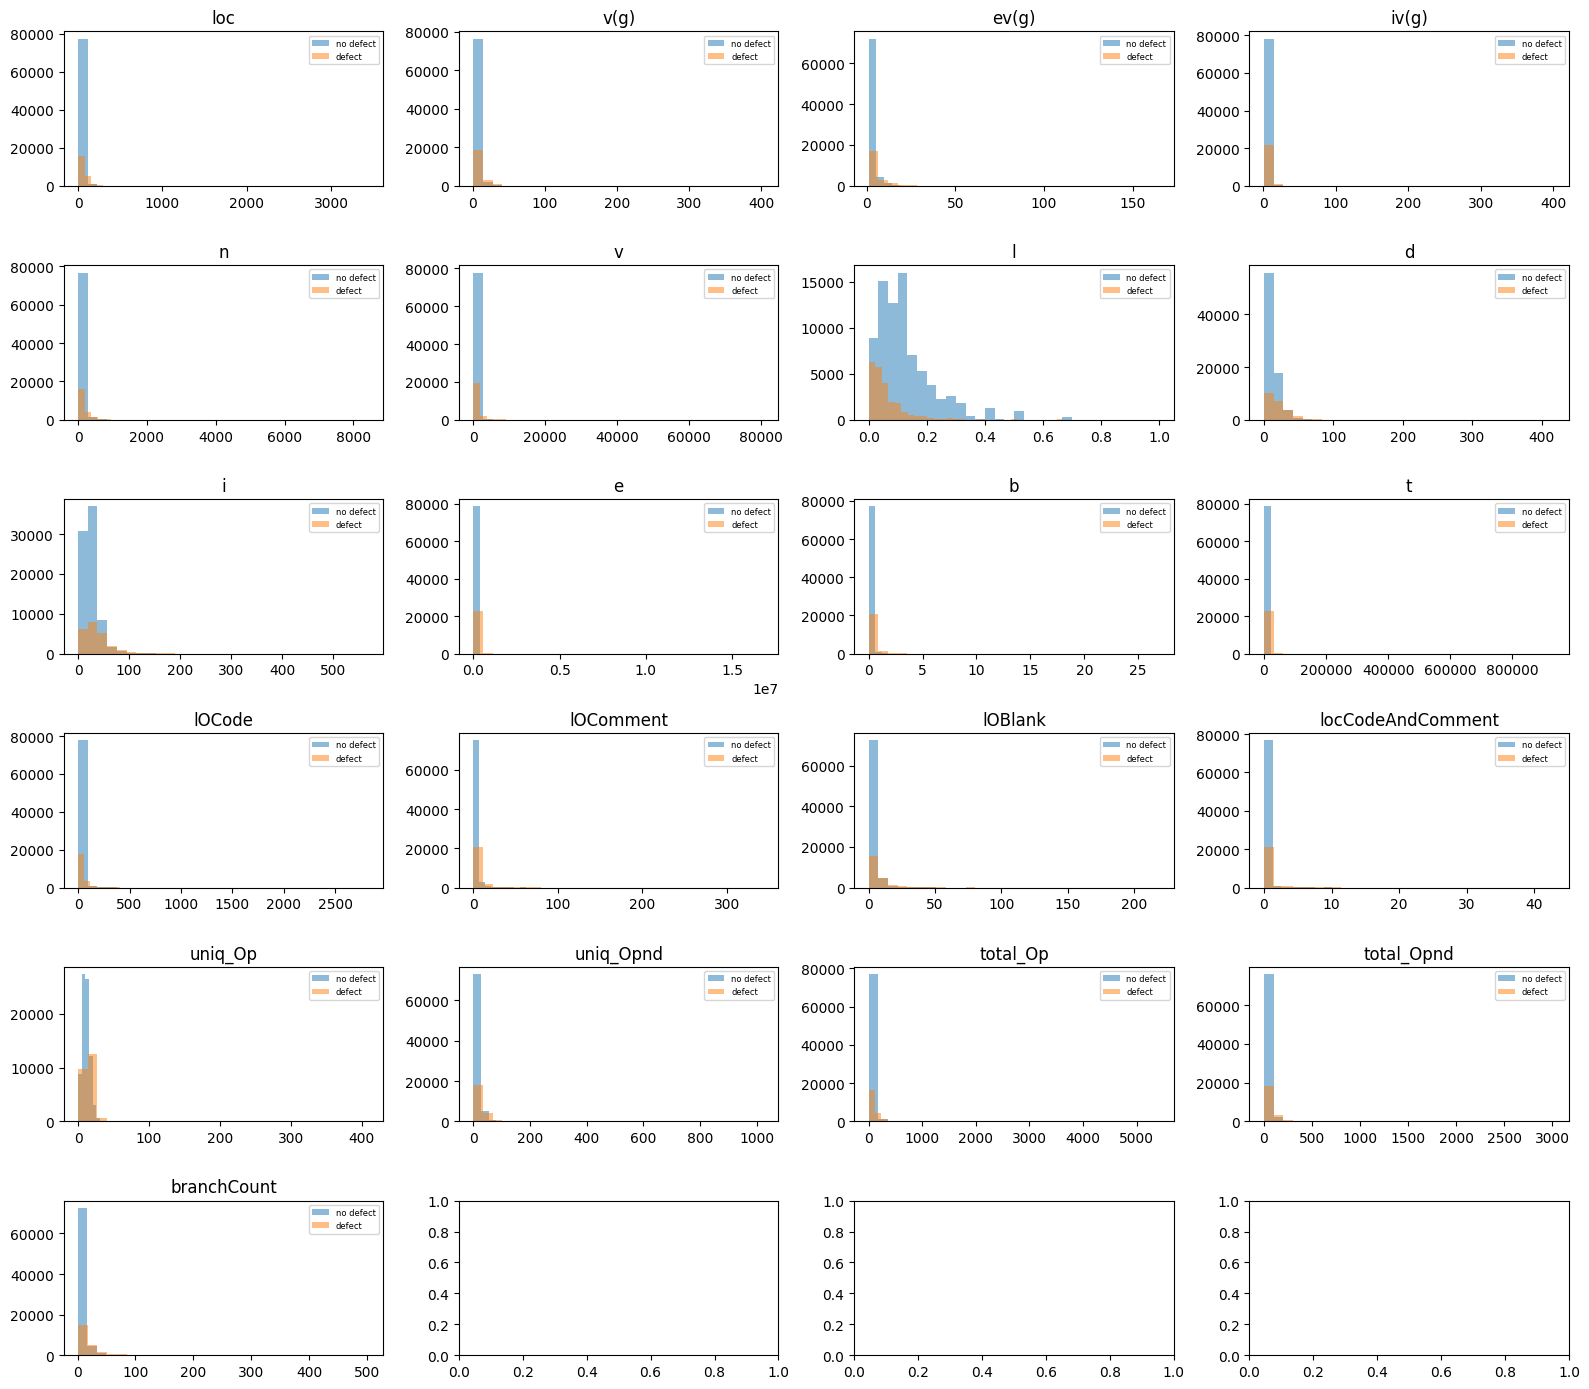

In [67]:
#This is before rescaling and dealing with outliers, so the graphs will inherently depict raw/messy data. 
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df[TARGET]==0][col], alpha=0.5, label="no defect", bins=30)
    axes[i].hist(df[df[TARGET]==1][col], alpha=0.5, label="defect", bins=30)
    axes[i].set_title(col)
    axes[i].legend(fontsize=6)

plt.tight_layout()
plt.show()

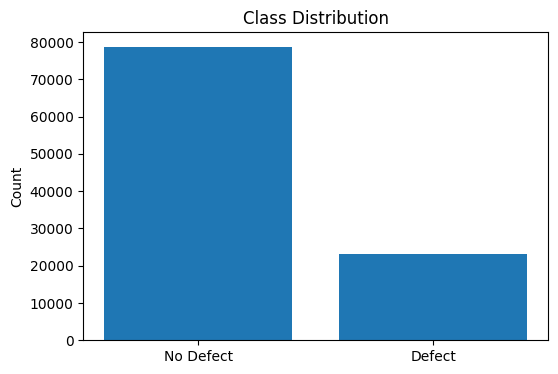

In [68]:
counts = df[TARGET].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['No Defect', 'Defect'], [counts[0], counts[1]])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

In [69]:
#this chart displays the obvious class imbalance that will be handled later down the line 

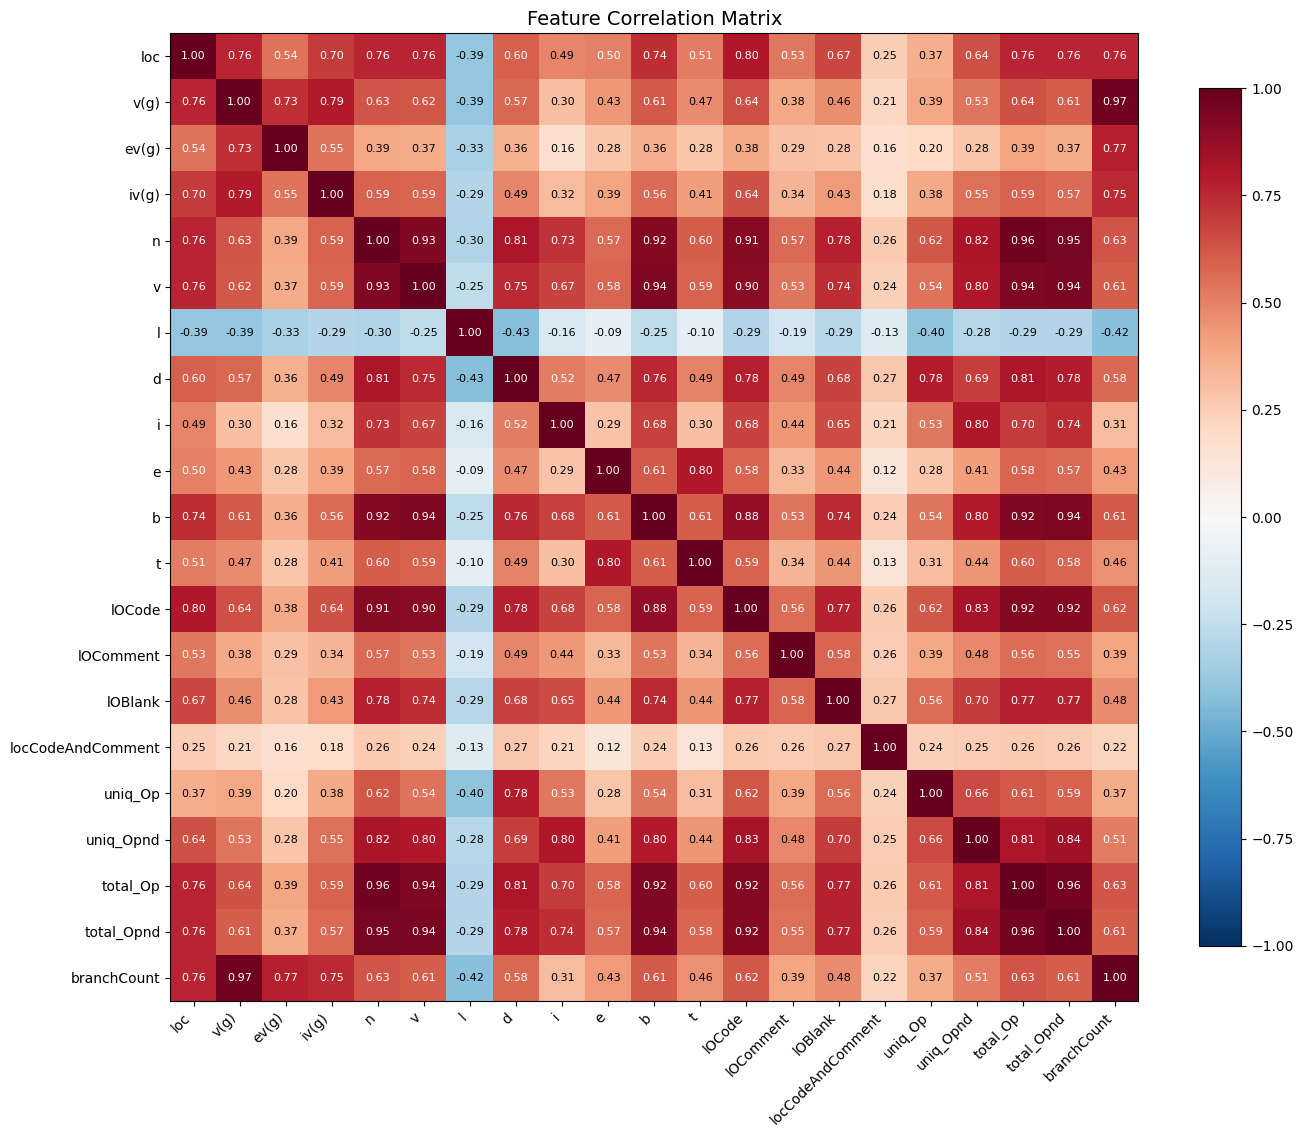

In [70]:
import matplotlib.pyplot as plt
import numpy as np

corr = df[features].corr()
feature_names = features

fig, ax = plt.subplots(figsize=(14,12))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        text = ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

# Labels
ax.set_xticks(np.arange(len(feature_names)))
ax.set_yticks(np.arange(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticklabels(feature_names)
ax.set_title('Feature Correlation Matrix', fontsize=14)

# Colorbar
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [71]:
df.corr()["defects"].drop("defects").sort_values(ascending=False)

loc                  0.342642
branchCount          0.322827
v(g)                 0.301187
ev(g)                0.259928
n                    0.258080
lOBlank              0.257819
total_Opnd           0.252752
lOCode               0.250604
total_Op             0.250533
uniq_Opnd            0.246113
iv(g)                0.245618
d                    0.241936
b                    0.232594
v                    0.231179
i                    0.208577
lOComment            0.205402
uniq_Op              0.178474
locCodeAndComment    0.133150
t                    0.099592
e                    0.095366
id                   0.001976
l                   -0.253237
Name: defects, dtype: float64

In [88]:
#applying Log scaling to reduce skewness and outlir influence
import copy
df_original = copy.deepcopy(df)
df_log = df[features].apply(np.log1p)
df_log.head()


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,3.135494,1.386294,0.693147,1.098612,4.110874,5.633467,0.058269,3.023347,2.724580,8.603332,...,5.716073,2.890372,0.693147,0.693147,0.0,2.833213,2.302585,3.663562,3.135494,1.791759
1,2.708050,1.098612,0.693147,1.098612,3.496508,5.025655,0.131028,2.079442,3.096030,6.843441,...,3.971046,2.484907,0.000000,0.693147,0.0,2.484907,2.484907,2.944439,2.708050,1.386294
2,2.484907,1.098612,0.693147,1.098612,3.828641,5.291544,0.104360,2.202765,3.168003,7.470230,...,4.589549,2.197225,0.000000,0.693147,0.0,2.564949,2.484907,3.367296,2.890372,1.386294
3,2.197225,0.693147,0.693147,0.693147,3.178054,4.553982,0.173953,1.832581,2.937043,6.162599,...,3.307253,1.609438,0.000000,1.098612,0.0,2.197225,1.945910,2.833213,2.079442,0.693147
4,2.484907,1.098612,0.693147,1.098612,2.890372,4.126166,0.165514,1.891605,2.598235,5.904462,...,3.059176,2.079442,0.000000,1.098612,0.0,2.079442,1.945910,2.397895,2.397895,1.386294


In [73]:
from sklearn.preprocessing import StandardScaler
#Scaling data to ensure not one single feature dominates due to higher range
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_log), columns=features)

df_scaled.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,-0.116911,-0.283304,-0.569539,-0.354383,0.206128,0.231328,-0.521675,0.750840,-0.296149,0.424120,...,0.422047,0.257178,0.287558,-0.626502,-0.266654,0.611742,-0.141983,0.233234,0.110793,-0.195105
1,-0.622822,-0.702091,-0.569539,-0.354383,-0.221785,-0.095076,0.343577,-0.248965,0.071879,-0.204178,...,-0.356593,-0.105524,-0.543222,-0.626502,-0.266654,0.166892,0.049918,-0.309951,-0.227723,-0.663313
2,-0.886928,-0.702091,-0.569539,-0.354383,0.009550,0.047711,0.026439,-0.118339,0.143189,0.019591,...,-0.080614,-0.362865,-0.543222,-0.626502,-0.266654,0.269121,0.049918,0.009452,-0.083333,-0.663313
3,-1.227420,-1.292337,-0.569539,-1.076075,-0.443592,-0.348371,0.854040,-0.510445,-0.085643,-0.447245,...,-0.652781,-0.888658,-0.543222,-0.143598,-0.266654,-0.200530,-0.517399,-0.393964,-0.725552,-1.463720
4,-0.886928,-0.702091,-0.569539,-0.354383,-0.643966,-0.578114,0.753685,-0.447926,-0.421329,-0.539402,...,-0.763474,-0.468225,-0.543222,-0.143598,-0.266654,-0.350961,-0.517399,-0.722779,-0.473351,-0.663313


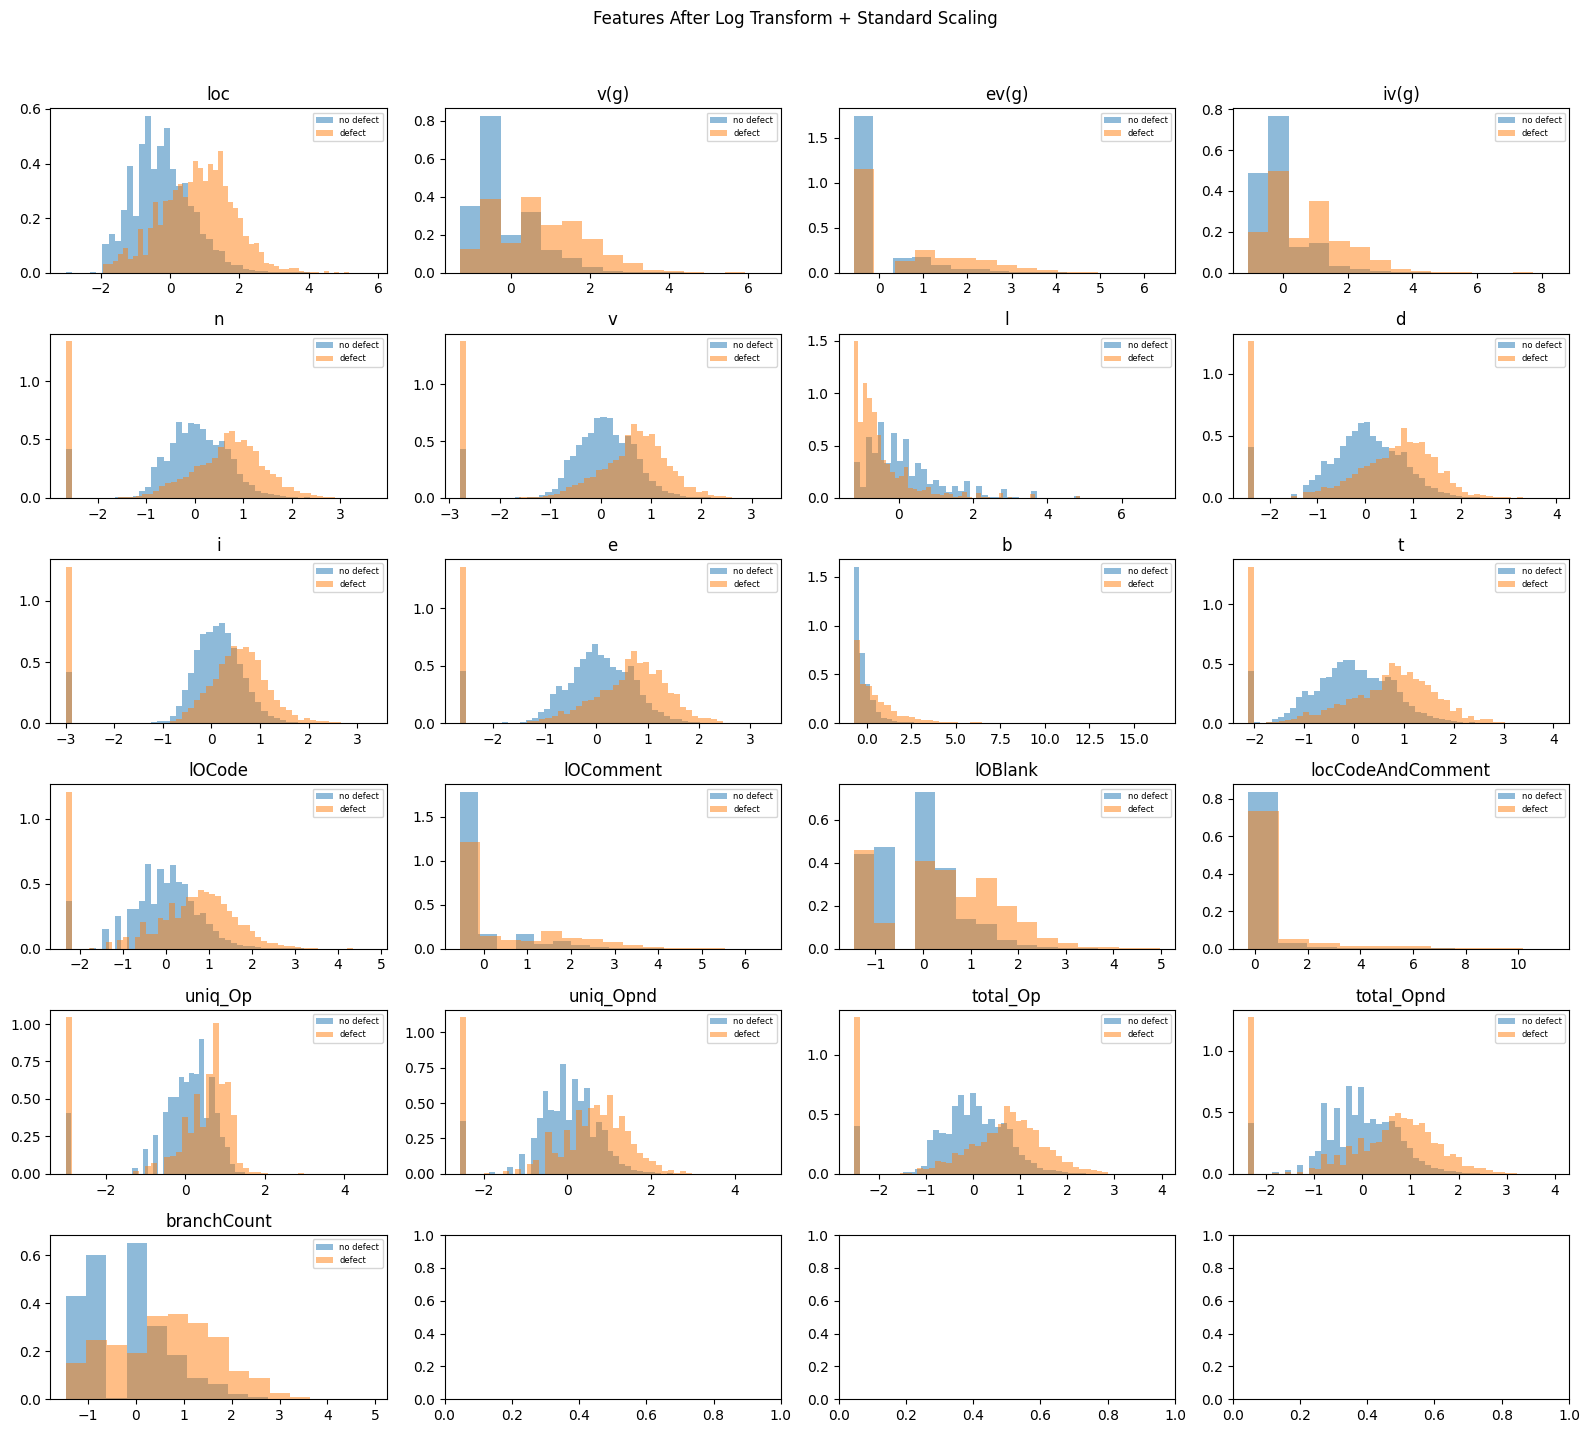

In [89]:
#plots to shoew histograms after rescaling
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 14))
axes = axes.flatten()
#adjusting Bin sizes for certain features for more clarity 
bin_sizes = {col: 50 for col in features}
bin_sizes["v(g)"] = 15
bin_sizes["ev(g)"] = 15
bin_sizes["iv(g)"] = 15
bin_sizes["lOComment"] = 15
bin_sizes["lOBlank"] = 15
bin_sizes["locCodeAndComment"] = 10
bin_sizes["branchCount"] = 15

for i, col in enumerate(features):
    axes[i].hist(df_scaled[df[TARGET]==0][col], alpha=0.5, label="no defect", bins=bin_sizes[col], density=True)
    axes[i].hist(df_scaled[df[TARGET]==1][col], alpha=0.5, label="defect", bins=bin_sizes[col], density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=6)

plt.suptitle("Features After Log Transform + Standard Scaling", y=1.02)
plt.tight_layout()
plt.show()

In [75]:
from sklearn.model_selection import train_test_split

# Features (scaled) and target
X = df_scaled
y = df[TARGET]

# Split into train (60%), validation (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (61057, 21)
Validation size: (20353, 21)
Test size: (20353, 21)


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate and train
lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Evaluate on validation set
y_pred_lr = lr.predict(X_val)

print("Logistic Regression - Validation Results")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(classification_report(y_val, y_pred_lr, target_names=["no defect", "defect"]))

Logistic Regression - Validation Results
Accuracy: 0.7405
              precision    recall  f1-score   support

   no defect       0.89      0.76      0.82     15693
      defect       0.46      0.68      0.55      4660

    accuracy                           0.74     20353
   macro avg       0.67      0.72      0.68     20353
weighted avg       0.79      0.74      0.76     20353



In [77]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train. also balancing defect and no defect weights
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

# Evaluate on validation set
y_pred_rf = rf.predict(X_val)

print("Random Forest - Validation Results")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(classification_report(y_val, y_pred_rf, target_names=["no defect", "defect"]))

Random Forest - Validation Results
Accuracy: 0.8048
              precision    recall  f1-score   support

   no defect       0.83      0.94      0.88     15693
      defect       0.64      0.34      0.44      4660

    accuracy                           0.80     20353
   macro avg       0.73      0.64      0.66     20353
weighted avg       0.78      0.80      0.78     20353



In [78]:
from xgboost import XGBClassifier
#implemented to give more weight to the defect class b/c its imbalanced
scale_pos_weight = 78699 / 23064

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_estimators=100, eval_metric="logloss")
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

print("XGBoost - Validation Results")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(classification_report(y_val, y_pred_xgb, target_names=["no defect", "defect"]))

XGBoost - Validation Results
Accuracy: 0.7517
              precision    recall  f1-score   support

   no defect       0.88      0.78      0.83     15693
      defect       0.47      0.64      0.54      4660

    accuracy                           0.75     20353
   macro avg       0.68      0.71      0.69     20353
weighted avg       0.79      0.75      0.76     20353



In [79]:
from IPython.display import HTML, display
import tabulate

lr_report = classification_report(y_val, y_pred_lr, output_dict=True)
rf_report = classification_report(y_val, y_pred_rf, output_dict=True)
xgb_report = classification_report(y_val, y_pred_xgb, output_dict=True)

rows = [["Logistic Regression",f"{accuracy_score(y_val, y_pred_lr):.4f}", f"{lr_report['1']['precision']:.4f}", f"{lr_report['1']['recall']:.4f}", f"{lr_report['1']['f1-score']:.4f}"],
    ["Random Forest",f"{accuracy_score(y_val, y_pred_rf):.4f}", f"{rf_report['1']['precision']:.4f}", f"{rf_report['1']['recall']:.4f}", f"{rf_report['1']['f1-score']:.4f}"],
    ["XGBoost",f"{accuracy_score(y_val, y_pred_xgb):.4f}", f"{xgb_report['1']['precision']:.4f}", f"{xgb_report['1']['recall']:.4f}", f"{xgb_report['1']['f1-score']:.4f}"],]

headers = ["Model", "Accuracy", "Defect Precision", "Defect Recall", "Defect F1"]
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

Model,Accuracy,Defect Precision,Defect Recall,Defect F1
Logistic Regression,0.7405,0.4555,0.6837,0.5468
Random Forest,0.8048,0.6384,0.3406,0.4442
XGBoost,0.7517,0.4692,0.6446,0.5431


In [82]:
# Evaluate all models on held out test set
lr_test_report = classification_report(y_test, lr.predict(X_test), output_dict=True)
rf_test_report = classification_report(y_test, rf.predict(X_test), output_dict=True)
xgb_test_report = classification_report(y_test, xgb.predict(X_test), output_dict=True)

print("Logistic Regression - Test Results")
print(classification_report(y_test, lr.predict(X_test), target_names=["no defect", "defect"]))

print("Random Forest - Test Results")
print(classification_report(y_test, rf.predict(X_test), target_names=["no defect", "defect"]))

print("XGBoost - Test Results")
print(classification_report(y_test, xgb.predict(X_test), target_names=["no defect", "defect"]))

Logistic Regression - Test Results
              precision    recall  f1-score   support

   no defect       0.89      0.75      0.82     15865
      defect       0.44      0.68      0.53      4488

    accuracy                           0.74     20353
   macro avg       0.67      0.72      0.68     20353
weighted avg       0.79      0.74      0.75     20353

Random Forest - Test Results
              precision    recall  f1-score   support

   no defect       0.84      0.94      0.88     15865
      defect       0.62      0.35      0.44      4488

    accuracy                           0.81     20353
   macro avg       0.73      0.64      0.66     20353
weighted avg       0.79      0.81      0.79     20353

XGBoost - Test Results
              precision    recall  f1-score   support

   no defect       0.88      0.78      0.83     15865
      defect       0.45      0.64      0.53      4488

    accuracy                           0.75     20353
   macro avg       0.67      0.71      0.

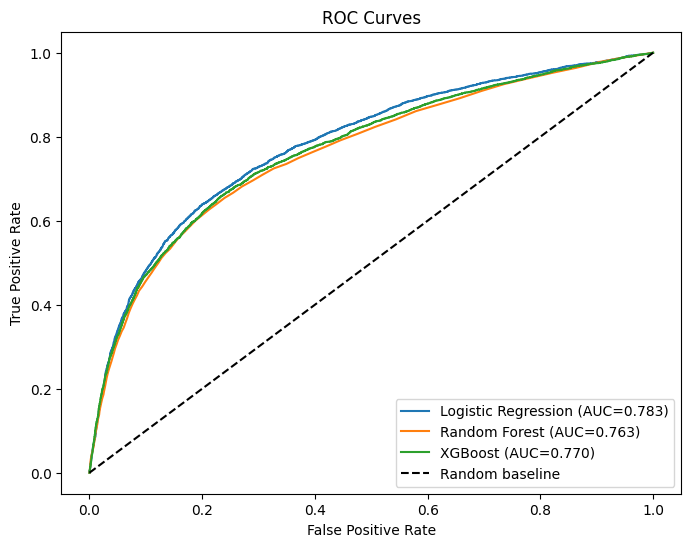

In [90]:
# ROC curves for test slice results
plt.figure(figsize=(8, 6))

for model, name in [(lr, "Logistic Regression"), (rf, "Random Forest"), (xgb, "XGBoost")]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [85]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")

Logistic Regression AUC: 0.7827
Random Forest AUC:       0.7633
XGBoost AUC:             0.7703


In [91]:
test_df = pd.read_csv("test.csv")

# Apply same transformations as training data
test_log = test_df[features].apply(np.log1p)
test_scaled = pd.DataFrame(scaler.transform(test_log), columns=features)

# Generate predictions using Logistic Regression
test_preds = lr.predict(test_scaled)

submission = pd.DataFrame({
    "id": test_df["id"],
    "defects": test_preds.astype(bool)
})

submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)

       id  defects
0  101763    False
1  101764    False
2  101765     True
3  101766     True
4  101767    False
(67842, 2)
